# Apple Stock Price Prediction Using an LSTM-Based Recurrent Neural Network

## Introduction

This KIE4031 Machine Learning final summative assessment predicts Apple's next-day closing stock price using historical market data. The main stock ticker is **AAPL**, and the data source is Yahoo Finance through the `yfinance` library.

This improved version tests whether prediction accuracy can be improved by adding more information than closing price alone. It compares three models:

- Close-only LSTM baseline
- Enhanced LSTM using OHLCV data and technical indicators
- Random Forest Regressor using the same enhanced 60-day windows

Stock price prediction is difficult because markets are affected by news, earnings reports, macroeconomic conditions, interest rates, investor sentiment, and unexpected events. This notebook is an educational time-series forecasting study, not a real trading system.

## 1. Library Setup

The required libraries are listed in `requirements.txt`. If any package is missing, install the dependencies using:

```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

YFINANCE_CACHE_DIR = Path(".yfinance_cache")
YFINANCE_CACHE_DIR.mkdir(exist_ok=True)
yf.set_tz_cache_location(str(YFINANCE_CACHE_DIR))

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data Collection

Apple historical stock data is downloaded from Yahoo Finance. The study period is `2015-01-01` to `2025-12-31`. Because `yfinance` treats the end date as exclusive, the download request uses `2026-01-01` so that the final trading day of 2025 is included.

In [2]:
ticker = "AAPL"
start_date = "2015-01-01"
end_date = "2026-01-01"
csv_path = Path("AAPL_stock_data.csv")

try:
    data = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
except Exception as error:
    print(f"Yahoo Finance download failed: {error}")
    data = pd.DataFrame()

if data.empty and csv_path.exists():
    print("Using cached AAPL_stock_data.csv because a fresh Yahoo Finance download was not available.")
    data = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date")
elif data.empty:
    raise RuntimeError("No AAPL data was downloaded and no cached AAPL_stock_data.csv file was found.")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = [column[0] for column in data.columns]

data = data.sort_index()
data.to_csv(csv_path, index_label="Date")

print("Dataset saved as AAPL_stock_data.csv")
print("Dataset shape:", data.shape)
print("Column names:", list(data.columns))

display(data.head())
display(data.tail())
display(data.describe())

Using cached AAPL_stock_data.csv because a fresh Yahoo Finance download was not available.
Dataset saved as AAPL_stock_data.csv
Dataset shape: (2766, 6)
Column names: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


            Adj Close      Close       High        Low       Open     Volume
Date                                                                        
2015-01-02  24.192610  27.332500  27.860001  26.837500  27.847500  212818400
2015-01-05  23.511061  26.562500  27.162500  26.352501  27.072500  257142000
2015-01-06  23.513279  26.565001  26.857500  26.157499  26.635000  263188400
2015-01-07  23.842985  26.937500  27.049999  26.674999  26.799999  160423600
2015-01-08  24.759089  27.972500  28.037500  27.174999  27.307501  237458000

             Adj Close       Close  ...        Open    Volume
Date                                ...                      
2025-12-24  273.302216  273.809998  ...  272.339996  17910600
2025-12-26  272.893005  273.399994  ...  274.160004  21521800
2025-12-29  273.252350  273.760010  ...  272.690002  23715200
2025-12-30  272.573547  273.079987  ...  272.809998  22139600
2025-12-31  271.355835  271.859985  ...  273.059998  27293600

[5 rows x 6 columns]

         Adj Close        Close  ...         Open        Volume
count  2766.000000  2766.000000  ...  2766.000000  2.766000e+03
mean    106.127485   108.644931  ...   108.546994  1.113994e+08
std      74.183369    73.856228  ...    73.777601  6.804243e+07
min      20.565866    22.584999  ...    22.500000  1.791060e+07
25%      36.583483    39.080626  ...    39.160000  6.488962e+07
50%      88.307220    91.204998  ...    91.176250  9.454380e+07
75%     168.334442   170.830006  ...   170.955002  1.372937e+08
max     285.659271   286.190002  ...   286.200012  6.488252e+08

[8 rows x 6 columns]

$AAPL: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)

1 Failed download:
['AAPL']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)


## 3. Data Cleaning

The data cleaning process checks missing values and duplicate rows, removes them if present, and keeps the rows sorted chronologically. Correct date order is essential because the model learns from previous trading days to predict the next day.

In [3]:
print("Missing values before cleaning:")
display(data.isna().sum().to_frame("Missing Values"))

duplicate_rows = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

if duplicate_rows > 0:
    data = data.drop_duplicates()
    print("Duplicate rows were dropped.")
else:
    print("No duplicate rows found.")

data = data.dropna().sort_index()
data.index = pd.to_datetime(data.index)
data.index.name = "Date"

print("Missing values after cleaning:")
display(data.isna().sum().to_frame("Missing Values"))
print("Cleaned dataset shape:", data.shape)

Missing values before cleaning:
Number of duplicate rows: 0
No duplicate rows found.
Missing values after cleaning:
Cleaned dataset shape: (2766, 6)


           Missing Values
Adj Close               0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0

           Missing Values
Adj Close               0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0

## 4. Exploratory Data Visualization

The following graphs show Apple's closing price trend, trading volume, and moving averages. These plots provide context before model training.

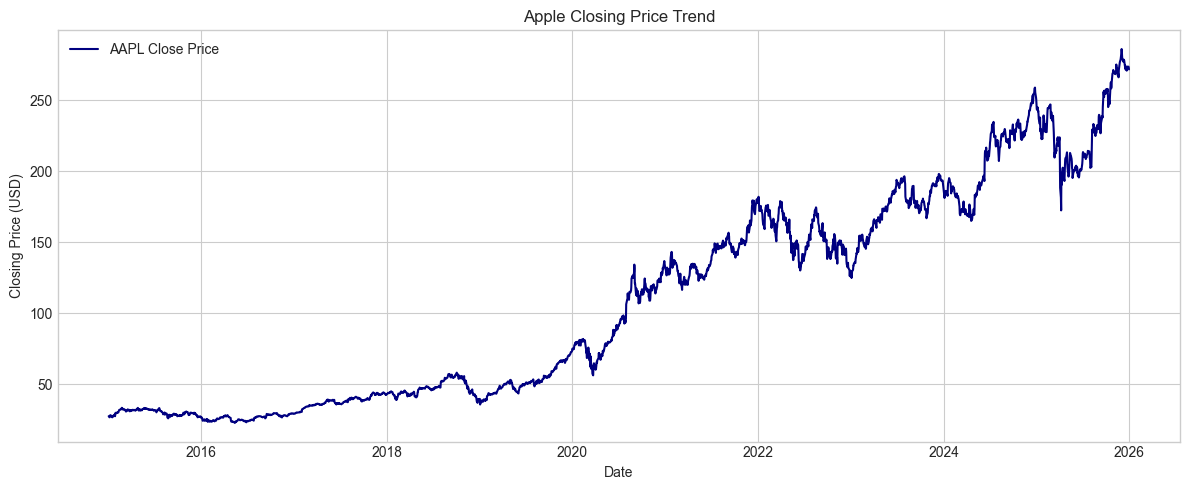

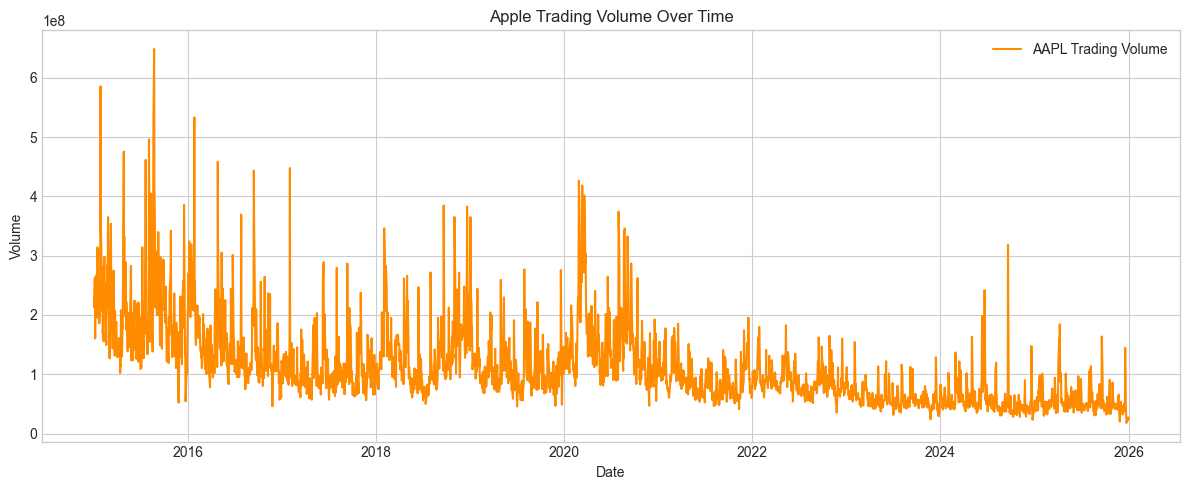

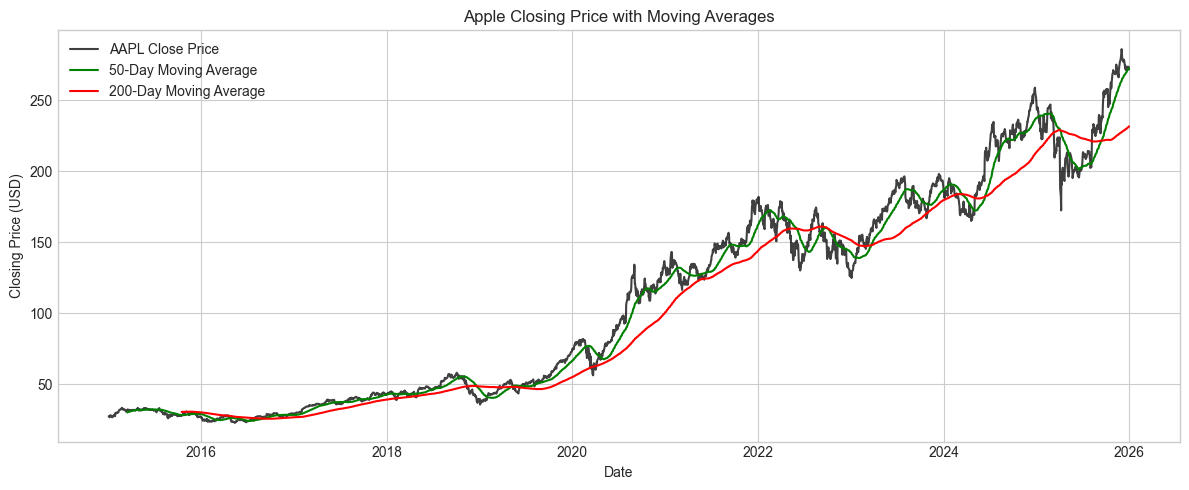

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"], label="AAPL Close Price", color="navy")
plt.title("Apple Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_01_close_price_trend.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Volume"], label="AAPL Trading Volume", color="darkorange")
plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_02_volume_trend.png", dpi=150)
plt.show()

eda_data = data.copy()
eda_data["MA_50"] = eda_data["Close"].rolling(window=50).mean()
eda_data["MA_200"] = eda_data["Close"].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(eda_data.index, eda_data["Close"], label="AAPL Close Price", color="black", alpha=0.75)
plt.plot(eda_data.index, eda_data["MA_50"], label="50-Day Moving Average", color="green")
plt.plot(eda_data.index, eda_data["MA_200"], label="200-Day Moving Average", color="red")
plt.title("Apple Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_03_moving_averages.png", dpi=150)
plt.show()

## 5. Feature Engineering

The original notebook used only `Close` price. This enhanced version adds OHLCV features and technical indicators that may help the model understand momentum, trend, volatility, and trading activity.

The added indicators are:

- Daily return
- 20-day, 50-day, and 200-day moving averages
- 14-day RSI
- MACD and MACD signal
- Bollinger Band upper and lower bands
- 20-day rolling volatility

These indicators are calculated only from current and past values, so they do not use future data.

In [5]:
def add_technical_indicators(df):
    feature_df = df.copy()
    feature_df["Return"] = feature_df["Close"].pct_change()
    feature_df["MA_20"] = feature_df["Close"].rolling(window=20).mean()
    feature_df["MA_50"] = feature_df["Close"].rolling(window=50).mean()
    feature_df["MA_200"] = feature_df["Close"].rolling(window=200).mean()

    delta = feature_df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / (avg_loss + 1e-8)
    feature_df["RSI_14"] = 100 - (100 / (1 + rs))

    ema_12 = feature_df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = feature_df["Close"].ewm(span=26, adjust=False).mean()
    feature_df["MACD"] = ema_12 - ema_26
    feature_df["MACD_Signal"] = feature_df["MACD"].ewm(span=9, adjust=False).mean()

    rolling_mean = feature_df["Close"].rolling(window=20).mean()
    rolling_std = feature_df["Close"].rolling(window=20).std()
    feature_df["BB_Upper"] = rolling_mean + (2 * rolling_std)
    feature_df["BB_Lower"] = rolling_mean - (2 * rolling_std)
    feature_df["Rolling_Volatility_20"] = feature_df["Return"].rolling(window=20).std()

    return feature_df


model_data = add_technical_indicators(data)
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna()

feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "MA_20",
    "MA_50",
    "MA_200",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "BB_Upper",
    "BB_Lower",
    "Rolling_Volatility_20",
]

target_column = "Close"

print("Feature columns used by the enhanced model:")
print(feature_columns)
print("Model dataset shape after indicator calculation:", model_data.shape)
display(model_data[feature_columns].head())

Feature columns used by the enhanced model:
['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'MA_20', 'MA_50', 'MA_200', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'Rolling_Volatility_20']
Model dataset shape after indicator calculation: (2567, 16)


                 Open     High  ...   BB_Lower  Rolling_Volatility_20
Date                            ...                                  
2015-10-16  27.945000  28.0000  ...  27.002031               0.013303
2015-10-19  27.700001  27.9375  ...  27.050024               0.012851
2015-10-20  27.834999  28.5425  ...  27.043366               0.013110
2015-10-21  28.500000  28.8950  ...  27.057529               0.012978
2015-10-22  28.582500  28.8750  ...  27.035618               0.013372

[5 rows x 15 columns]

## 6. Train-Test Split, Scaling, and No Data Leakage

The data is split chronologically using 80% for training and 20% for testing. The data is not shuffled. To avoid data leakage, all scalers are fitted only on the training period.

This experiment compares:

- A close-only LSTM that directly predicts next-day closing price
- An enhanced LSTM that predicts next-day return using OHLCV and indicators, then reconstructs closing price
- A Random Forest return model using the same enhanced 60-day windows

Predicting returns is often more stable than predicting raw price levels because returns are less affected by long-term price scale changes.

In [6]:
lookback = 60
train_size_raw = int(len(model_data) * 0.8)

train_df = model_data.iloc[:train_size_raw]
test_df = model_data.iloc[train_size_raw:]

feature_scaler = MinMaxScaler(feature_range=(0, 1))
price_scaler = MinMaxScaler(feature_range=(0, 1))
return_scaler = MinMaxScaler(feature_range=(-1, 1))

feature_scaler.fit(train_df[feature_columns])
price_scaler.fit(train_df[["Close"]])
return_scaler.fit(train_df[["Return"]])

all_features_scaled = feature_scaler.transform(model_data[feature_columns])
all_close_scaled = price_scaler.transform(model_data[["Close"]])
all_return_scaled = return_scaler.transform(model_data[["Return"]]).reshape(-1)

print("Training period:", train_df.index.min().date(), "to", train_df.index.max().date())
print("Testing period:", test_df.index.min().date(), "to", test_df.index.max().date())
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training period: 2015-10-16 to 2023-12-12
Testing period: 2023-12-13 to 2025-12-31
Training rows: 2053
Testing rows: 514


## 7. Sequence Preparation

A 60-day lookback window means that each input sample contains the previous 60 trading days. For the close-only baseline, the target is next-day closing price. For the enhanced model, the target is next-day return, which is later converted back into a predicted closing price.

In [7]:
def create_sequences(feature_values, target_values, lookback_window):
    X, y = [], []
    for i in range(lookback_window, len(feature_values)):
        X.append(feature_values[i - lookback_window:i])
        y.append(target_values[i])
    return np.array(X), np.array(y)


X_close_all, y_price_all = create_sequences(all_close_scaled, all_close_scaled.reshape(-1), lookback)
X_enhanced_all, y_return_all = create_sequences(all_features_scaled, all_return_scaled, lookback)

sequence_dates = model_data.index[lookback:]
actual_close_all = model_data["Close"].iloc[lookback:].to_numpy()
previous_close_all = model_data["Close"].iloc[lookback - 1:-1].to_numpy()

train_sequence_count = train_size_raw - lookback

X_train_close = X_close_all[:train_sequence_count]
X_test_close = X_close_all[train_sequence_count:]
X_train_enhanced = X_enhanced_all[:train_sequence_count]
X_test_enhanced = X_enhanced_all[train_sequence_count:]

y_train_price = y_price_all[:train_sequence_count]
y_test_price = y_price_all[train_sequence_count:]
y_train_return = y_return_all[:train_sequence_count]
y_test_return = y_return_all[train_sequence_count:]

train_dates = sequence_dates[:train_sequence_count]
test_dates = sequence_dates[train_sequence_count:]
actual_close_test = actual_close_all[train_sequence_count:]
previous_close_test = previous_close_all[train_sequence_count:]

print("Close-only X_train shape:", X_train_close.shape)
print("Close-only X_test shape:", X_test_close.shape)
print("Enhanced X_train shape:", X_train_enhanced.shape)
print("Enhanced X_test shape:", X_test_enhanced.shape)
print("Price target train shape:", y_train_price.shape)
print("Return target train shape:", y_train_return.shape)
print("Training sequence period:", train_dates.min().date(), "to", train_dates.max().date())
print("Testing sequence period:", test_dates.min().date(), "to", test_dates.max().date())

Close-only X_train shape: (1993, 60, 1)
Close-only X_test shape: (514, 60, 1)
Enhanced X_train shape: (1993, 60, 15)
Enhanced X_test shape: (514, 60, 15)
Price target train shape: (1993,)
Return target train shape: (1993,)
Training sequence period: 2016-01-13 to 2023-12-12
Testing sequence period: 2023-12-13 to 2025-12-31


## 8. Model Development

Both LSTM models use the same compact architecture. The close-only model predicts scaled closing price. The enhanced model predicts scaled next-day return from OHLCV and indicator sequences. L2 regularization and dropout are used to reduce overfitting risk.

In [8]:
def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(
            units=32,
            return_sequences=True,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4),
        ),
        Dropout(0.3),
        LSTM(
            units=16,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4),
        ),
        Dropout(0.3),
        Dense(units=1),
    ])
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model


close_lstm_model = build_lstm_model((lookback, 1))
return_lstm_model = build_lstm_model((lookback, len(feature_columns)))

print("LSTM architecture: Input -> LSTM(32) -> Dropout(0.3) -> LSTM(16) -> Dropout(0.3) -> Dense(1)")
print("Regularization: L2(1e-4) on LSTM kernels and recurrent weights")
print(f"Close-only model input shape: {(lookback, 1)}")
print(f"Enhanced model input shape: {(lookback, len(feature_columns))}")

LSTM architecture: Input -> LSTM(32) -> Dropout(0.3) -> LSTM(16) -> Dropout(0.3) -> Dense(1)
Regularization: L2(1e-4) on LSTM kernels and recurrent weights
Close-only model input shape: (60, 1)
Enhanced model input shape: (60, 15)


## 9. Model Training

The models are trained with a maximum of 30 epochs, batch size 32, and a validation split of 10%. Early stopping is used to reduce overfitting. The time-series data is not shuffled.

Close-only LSTM epochs trained: 7
Return-target enhanced LSTM epochs trained: 30
Close-only final training loss: 0.012857
Close-only final validation loss: 0.037596
Return-target final training loss: 0.025008
Return-target final validation loss: 0.011296


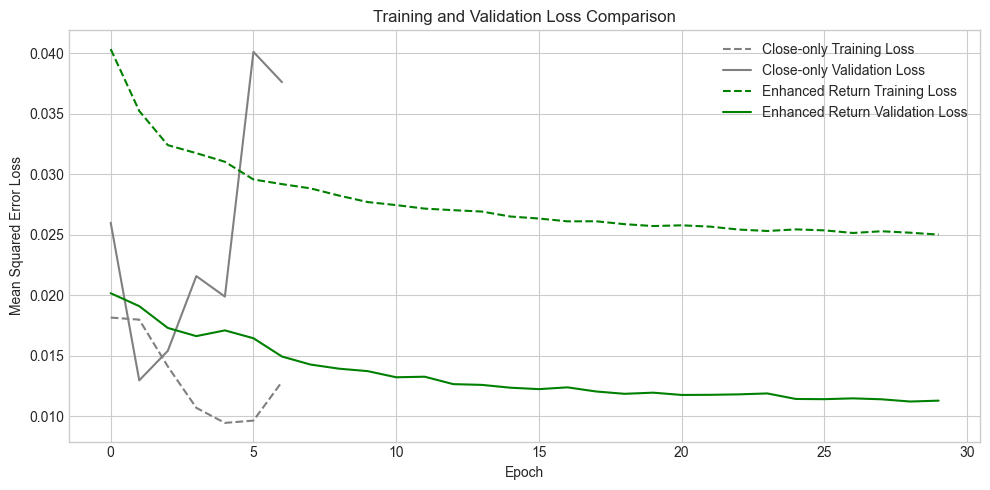

In [9]:
close_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

return_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

close_history = close_lstm_model.fit(
    X_train_close,
    y_train_price,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[close_early_stopping],
    verbose=0,
)

return_history = return_lstm_model.fit(
    X_train_enhanced,
    y_train_return,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[return_early_stopping],
    verbose=0,
)

print(f"Close-only LSTM epochs trained: {len(close_history.history['loss'])}")
print(f"Return-target enhanced LSTM epochs trained: {len(return_history.history['loss'])}")
print(f"Close-only final training loss: {close_history.history['loss'][-1]:.6f}")
print(f"Close-only final validation loss: {close_history.history['val_loss'][-1]:.6f}")
print(f"Return-target final training loss: {return_history.history['loss'][-1]:.6f}")
print(f"Return-target final validation loss: {return_history.history['val_loss'][-1]:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(close_history.history["loss"], label="Close-only Training Loss", linestyle="--", color="gray")
plt.plot(close_history.history["val_loss"], label="Close-only Validation Loss", color="gray")
plt.plot(return_history.history["loss"], label="Enhanced Return Training Loss", linestyle="--", color="green")
plt.plot(return_history.history["val_loss"], label="Enhanced Return Validation Loss", color="green")
plt.title("Training and Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_04_validation_loss_comparison.png", dpi=150)
plt.show()

## 10. Prediction and Evaluation

Price-level metrics can look very strong for stock forecasting because tomorrow's price is usually close to today's price. To avoid overclaiming, the evaluation includes a naive previous-close baseline and separate return-level metrics.

In [10]:
def calculate_price_metrics(actual, predicted, epsilon=1e-8):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / (actual + epsilon))) * 100
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE (%)": mape,
    }


def calculate_return_metrics(actual_return, predicted_return):
    return_mae = mean_absolute_error(actual_return, predicted_return) * 100
    return_rmse = np.sqrt(mean_squared_error(actual_return, predicted_return)) * 100
    directional_accuracy = (np.sign(actual_return) == np.sign(predicted_return)).mean() * 100
    return {
        "Return MAE (pct pts)": return_mae,
        "Return RMSE (pct pts)": return_rmse,
        "Directional Accuracy (%)": directional_accuracy,
    }


close_lstm_pred_scaled = close_lstm_model.predict(X_test_close, verbose=0)
close_lstm_pred = price_scaler.inverse_transform(close_lstm_pred_scaled).ravel()

actual_return_test = return_scaler.inverse_transform(y_test_return.reshape(-1, 1)).ravel()

return_lstm_pred_scaled = return_lstm_model.predict(X_test_enhanced, verbose=0)
return_lstm_pred = return_scaler.inverse_transform(return_lstm_pred_scaled).ravel()
return_lstm_close_pred = previous_close_test * (1 + return_lstm_pred)

naive_close_pred = previous_close_test.copy()
naive_return_pred = np.zeros_like(actual_return_test)
close_lstm_return_pred = (close_lstm_pred / previous_close_test) - 1

naive_price_metrics = calculate_price_metrics(actual_close_test, naive_close_pred)
close_lstm_price_metrics = calculate_price_metrics(actual_close_test, close_lstm_pred)
return_lstm_price_metrics = calculate_price_metrics(actual_close_test, return_lstm_close_pred)

price_comparison_df = pd.DataFrame(
    [naive_price_metrics, close_lstm_price_metrics, return_lstm_price_metrics],
    index=["Naive Previous Close", "Close-only Price LSTM", "Enhanced Return LSTM"],
)[["MAE", "RMSE", "R2 Score", "MAPE (%)"]]

return_comparison_df = pd.DataFrame(
    [
        calculate_return_metrics(actual_return_test, naive_return_pred),
        calculate_return_metrics(actual_return_test, close_lstm_return_pred),
        calculate_return_metrics(actual_return_test, return_lstm_pred),
    ],
    index=["Naive Zero Return", "Close-only Price LSTM", "Enhanced Return LSTM"],
)[["Return MAE (pct pts)", "Return RMSE (pct pts)", "Directional Accuracy (%)"]]
return_comparison_df.loc["Naive Zero Return", "Directional Accuracy (%)"] = np.nan

print("Price-level metrics")
display(price_comparison_df)

print("Return-level metrics")
display(return_comparison_df)

Price-level metrics
Return-level metrics


                             MAE       RMSE  R2 Score   MAPE (%)
Naive Previous Close    2.460681   3.643134  0.983889   1.143412
Close-only Price LSTM  34.349024  37.869265 -0.740801  15.013736
Enhanced Return LSTM    2.527477   3.688467  0.983485   1.169331

                       Return MAE (pct pts)  ...  Directional Accuracy (%)
Naive Zero Return                  1.145844  ...                       NaN
Close-only Price LSTM             15.044508  ...                 45.719844
Enhanced Return LSTM               1.173558  ...                 49.027237

[3 rows x 3 columns]

## 11. LSTM Result Visualization

The plot below compares the actual AAPL closing price with both LSTM approaches.

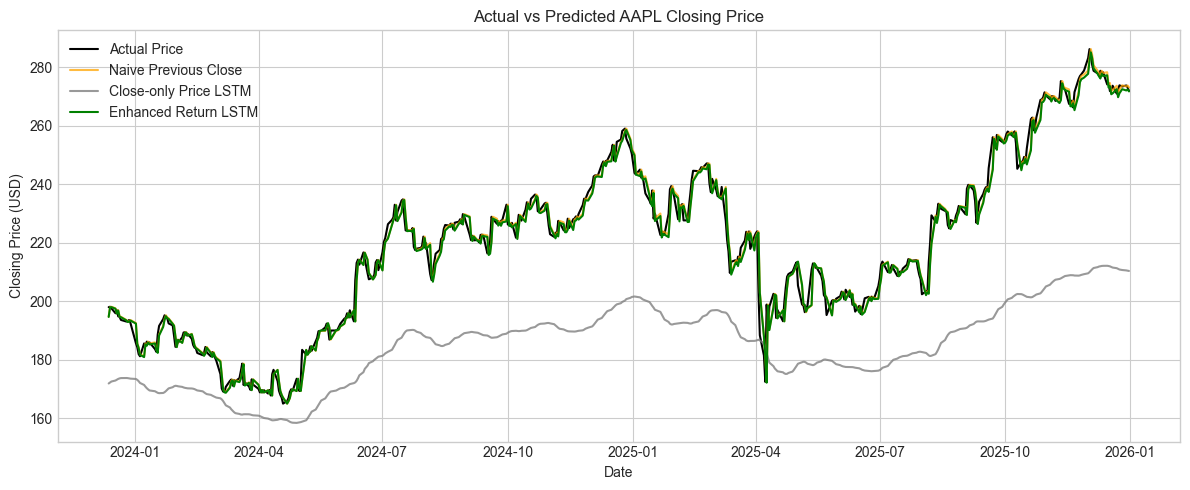

In [11]:
results_df = pd.DataFrame({
    "Date": test_dates,
    "Actual Price": actual_close_test,
    "Naive Previous Close Prediction": naive_close_pred,
    "Close-only LSTM Predicted Price": close_lstm_pred,
    "Enhanced Return LSTM Predicted Price": return_lstm_close_pred,
    "Actual Return": actual_return_test,
    "Enhanced LSTM Predicted Return": return_lstm_pred,
})

results_df["Enhanced LSTM Error"] = results_df["Actual Price"] - results_df["Enhanced Return LSTM Predicted Price"]
results_df["Naive Error"] = results_df["Actual Price"] - results_df["Naive Previous Close Prediction"]
results_df["Enhanced LSTM Absolute Error"] = results_df["Enhanced LSTM Error"].abs()
results_df["Enhanced LSTM Percentage Error (%)"] = (
    results_df["Enhanced LSTM Absolute Error"] / (results_df["Actual Price"].abs() + 1e-8)
) * 100

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["Actual Price"], label="Actual Price", color="black")
plt.plot(results_df["Date"], results_df["Naive Previous Close Prediction"], label="Naive Previous Close", color="orange", alpha=0.75)
plt.plot(results_df["Date"], results_df["Close-only LSTM Predicted Price"], label="Close-only Price LSTM", color="gray", alpha=0.8)
plt.plot(results_df["Date"], results_df["Enhanced Return LSTM Predicted Price"], label="Enhanced Return LSTM", color="green")
plt.title("Actual vs Predicted AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_05_lstm_actual_vs_predicted.png", dpi=150)
plt.show()

The return-target approach reduces scale-drift problems because it learns daily percentage movement instead of the raw price level. However, it must also be compared with the naive previous-close baseline because stock prices are highly autocorrelated.

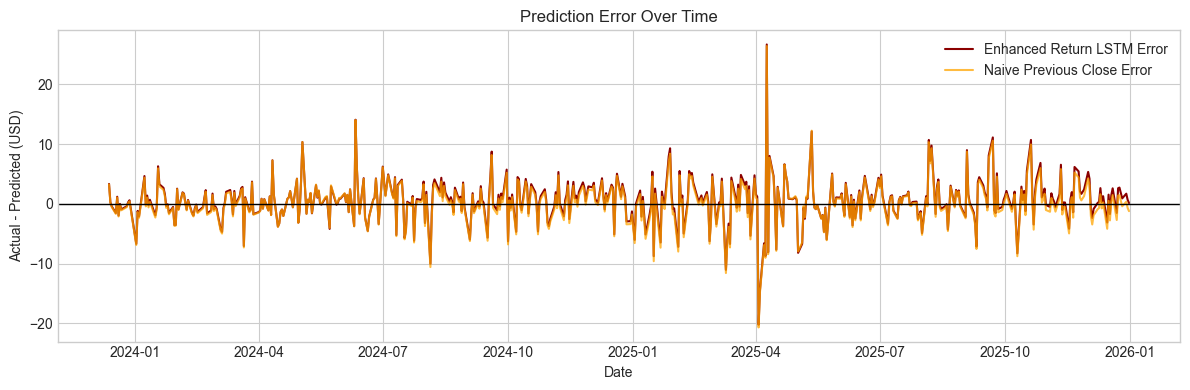

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(results_df["Date"], results_df["Enhanced LSTM Error"], label="Enhanced Return LSTM Error", color="darkred")
plt.plot(results_df["Date"], results_df["Naive Error"], label="Naive Previous Close Error", color="orange", alpha=0.75)
plt.axhline(0, color="black", linewidth=1)
plt.title("Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_06_lstm_prediction_error.png", dpi=150)
plt.show()

The error graph shows where the enhanced return-based LSTM over-predicts or under-predicts compared with a simple previous-close baseline. If the LSTM error is not consistently smaller than the naive error, the model is not adding much practical forecasting value.

## 12. Sample Prediction Table

The table below shows ten sample test-set predictions from the enhanced return-based LSTM.

In [13]:
sample_predictions = results_df[
    [
        "Date",
        "Actual Price",
        "Naive Previous Close Prediction",
        "Enhanced Return LSTM Predicted Price",
        "Enhanced LSTM Absolute Error",
        "Enhanced LSTM Percentage Error (%)",
    ]
].rename(
    columns={
        "Enhanced Return LSTM Predicted Price": "LSTM Predicted Price",
        "Enhanced LSTM Absolute Error": "LSTM Absolute Error",
        "Enhanced LSTM Percentage Error (%)": "LSTM Percentage Error (%)",
    }
)

display(sample_predictions.head(10))

        Date  Actual Price  ...  LSTM Absolute Error  LSTM Percentage Error (%)
0 2023-12-13    197.960007  ...             3.337611                   1.686003
1 2023-12-14    198.110001  ...             0.258359                   0.130412
2 2023-12-15    197.570007  ...             0.418132                   0.211637
3 2023-12-18    195.889999  ...             1.544500                   0.788453
4 2023-12-19    196.940002  ...             1.191469                   0.604991
5 2023-12-20    194.830002  ...             1.964431                   1.008280
6 2023-12-21    194.679993  ...             0.003607                   0.001853
7 2023-12-22    193.600006  ...             0.929404                   0.480064
8 2023-12-26    193.050003  ...             0.396597                   0.205438
9 2023-12-27    193.149994  ...             0.259312                   0.134254

[10 rows x 6 columns]

## 13. Alternative Model Comparison

Random Forest Regressor is trained on the same enhanced 60-day input windows and return target. The 3D LSTM input is flattened into 2D features for Random Forest.

Price-level model comparison
Return-level model comparison


                                  MAE       RMSE  R2 Score   MAPE (%)
Naive Previous Close         2.460681   3.643134  0.983889   1.143412
Close-only Price LSTM       34.349024  37.869265 -0.740801  15.013736
Enhanced Return LSTM         2.527477   3.688467  0.983485   1.169331
Random Forest Return Model   2.525216   3.668167  0.983667   1.168957

                            Return MAE (pct pts)  ...  Directional Accuracy (%)
Naive Zero Return                       1.145844  ...                       NaN
Close-only Price LSTM                  15.044508  ...                 45.719844
Enhanced Return LSTM                    1.173558  ...                 49.027237
Random Forest Return Model              1.171452  ...                 51.361868

[4 rows x 3 columns]

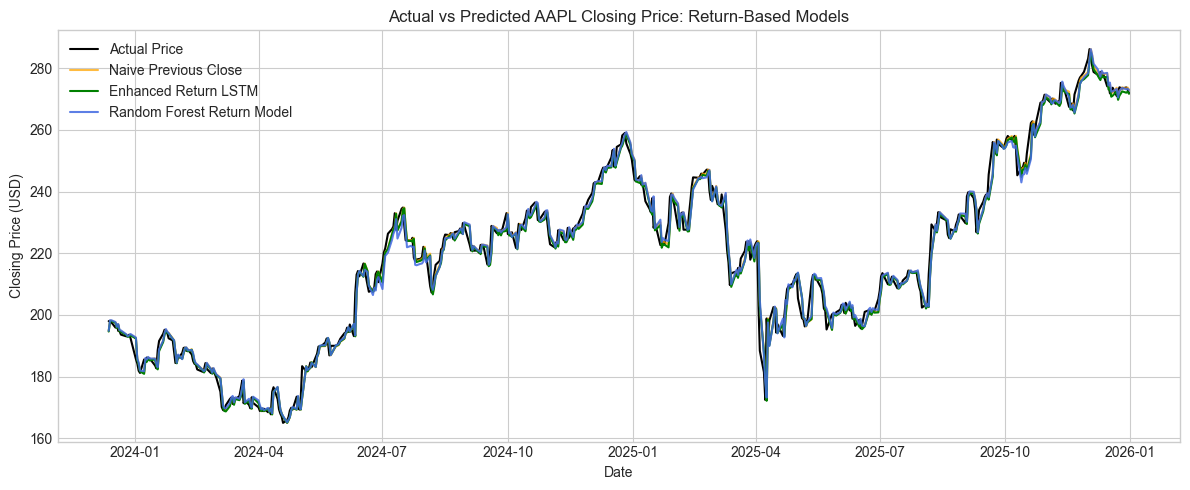

In [14]:
X_train_rf = X_train_enhanced.reshape(X_train_enhanced.shape[0], X_train_enhanced.shape[1] * X_train_enhanced.shape[2])
X_test_rf = X_test_enhanced.reshape(X_test_enhanced.shape[0], X_test_enhanced.shape[1] * X_test_enhanced.shape[2])

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train_return)

rf_return_scaled = rf_model.predict(X_test_rf).reshape(-1, 1)
rf_return_pred = return_scaler.inverse_transform(rf_return_scaled).ravel()
rf_close_pred = previous_close_test * (1 + rf_return_pred)

rf_price_metrics = calculate_price_metrics(actual_close_test, rf_close_pred)

comparison_df = pd.DataFrame(
    [naive_price_metrics, close_lstm_price_metrics, return_lstm_price_metrics, rf_price_metrics],
    index=[
        "Naive Previous Close",
        "Close-only Price LSTM",
        "Enhanced Return LSTM",
        "Random Forest Return Model",
    ],
)[["MAE", "RMSE", "R2 Score", "MAPE (%)"]]

rf_return_metrics = calculate_return_metrics(actual_return_test, rf_return_pred)

return_model_comparison_df = pd.DataFrame(
    [
        calculate_return_metrics(actual_return_test, naive_return_pred),
        calculate_return_metrics(actual_return_test, close_lstm_return_pred),
        calculate_return_metrics(actual_return_test, return_lstm_pred),
        rf_return_metrics,
    ],
    index=[
        "Naive Zero Return",
        "Close-only Price LSTM",
        "Enhanced Return LSTM",
        "Random Forest Return Model",
    ],
)[["Return MAE (pct pts)", "Return RMSE (pct pts)", "Directional Accuracy (%)"]]
return_model_comparison_df.loc["Naive Zero Return", "Directional Accuracy (%)"] = np.nan

print("Price-level model comparison")
display(comparison_df)

print("Return-level model comparison")
display(return_model_comparison_df)

results_df["Random Forest Predicted Price"] = rf_close_pred

plt.figure(figsize=(12, 5))
plt.plot(results_df["Date"], results_df["Actual Price"], label="Actual Price", color="black")
plt.plot(results_df["Date"], results_df["Naive Previous Close Prediction"], label="Naive Previous Close", color="orange", alpha=0.75)
plt.plot(results_df["Date"], results_df["Enhanced Return LSTM Predicted Price"], label="Enhanced Return LSTM", color="green")
plt.plot(results_df["Date"], results_df["Random Forest Predicted Price"], label="Random Forest Return Model", color="royalblue", alpha=0.85)
plt.title("Actual vs Predicted AAPL Closing Price: Return-Based Models")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aapl_07_lstm_vs_random_forest.png", dpi=150)
plt.show()

## 14. Result Interpretation

Lower MAE, RMSE, and MAPE values indicate better price reconstruction accuracy. A higher R2 score indicates a better fit to the actual price level. However, price-level stock metrics can be misleading because a naive previous-close forecast is already very strong.

In this run, the enhanced return LSTM and Random Forest are close to the naive previous-close baseline, but they do not clearly beat it on the main price-error metrics. This suggests that the high price-level R2 score mostly reflects price persistence rather than strong independent forecasting power.

For this reason, the notebook also reports return-level MAE, return-level RMSE, and directional accuracy. These metrics are stricter because they evaluate whether the model adds useful information beyond the fact that consecutive prices are usually similar.

The result should be interpreted cautiously rather than as strong forecasting power. A more complex deep learning model is not automatically better. Model performance depends on the target design, feature set, training strategy, market period, and validation approach.

## Critical Analysis

### Strengths of LSTM

LSTM is suitable for sequential data because it processes ordered observations over time. It can learn time-dependent patterns from the previous 60 trading days and can capture general trend-following behaviour in Apple's historical stock price.

### Overfitting and Evaluation Risk

The model can still overfit because stock data is noisy and non-stationary. A prediction line that closely follows the actual price does not automatically prove strong forecasting ability, because stock prices are highly autocorrelated and a previous-close baseline can also look very accurate. In the evaluated run, the enhanced models were close to the naive baseline, which is a warning sign that the models may be learning persistence more than meaningful predictive structure. This is why the notebook includes both price-level and return-level metrics.

### Data and Market Limitations

The model depends heavily on historical market data. Even with Open, High, Low, Close, Volume, and technical indicators, it does not directly capture sudden news, earnings surprises, macroeconomic events, interest rate changes, or investor sentiment. The model may follow trends but react slowly during sharp reversals because it learns from past observations.

### Comparison with Random Forest

The LSTM naturally models sequential patterns, while Random Forest is simpler, faster, and easier to train. Random Forest does not naturally understand time order unless sequence features are manually created. In this notebook, the 60-day enhanced feature windows are flattened so Random Forest can use them.

This model should not be treated as a real trading system. Good prediction graphs do not guarantee profitable trading performance after risk, transaction costs, timing, and changing market conditions are considered.

## Conclusion

This project successfully implemented and evaluated an LSTM-based Recurrent Neural Network model for Apple stock price prediction. The improved experiment tested whether OHLCV features, technical indicators, regularization, and a return-based prediction target could improve accuracy compared with a close-only price-target LSTM baseline.

The model can learn general historical price trends, but the evaluation also shows why stock forecasting results must be interpreted carefully. Price-level metrics may appear strong because consecutive stock prices are usually close to each other. In this run, the enhanced models were close to the naive previous-close baseline, so the result should not be interpreted as a highly accurate trading predictor. The naive baseline and return-level metrics provide a more honest assessment of whether the model adds forecasting value.

This notebook should be treated as an educational forecasting model, not a trading system.

Future improvements could include tuning the LSTM architecture, adding sentiment analysis from financial news, adding macroeconomic features, comparing with GRU and Transformer models, and using walk-forward validation for a more realistic evaluation.

## Source Code Link

[Insert GitHub repository link here]